<a href="https://www.kaggle.com/code/raneemababneh/cleaning-dataset-iot-malware-network-traffic?scriptVersionId=329046688" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/raneemababneh/iot-malware-network-traffic-dataset-cic-ynu-2026/pcap.csv
/kaggle/input/datasets/raneemababneh/imagge/ChatGPT Image Jun 20 2026 10_30_57 PM.png


## Project Overview

### This notebook demonstrates the complete workflow for building machine learning models to detect IoT malware using the **CIC-YNU-IoTMal 2026** dataset.

The workflow includes:

- 📥 Importing libraries
- 📊 Loading the dataset
- 🔍 Exploratory Data Analysis (EDA)
- 🧹 Data preprocessing (Cleaning)
- ✂️ Train/Test split
- 🤖 Model training
- ⚙️ Hyperparameter tuning
- 📈 Performance evaluation
- 🏆 Model comparison

### ### Import Libraries :
### NumPy : Numerical computing and array operations.
### Pandas : Data loading, manipulation, and analysis. 
### Matplotlib : Data visualization and plotting.
### Seaborn : Statistical data visualization.
### Scikit-learn : Machine learning algorithms and utilities. 
### XGBoost : Gradient boosting classification model. 
### LightGBM :Fast gradient boosting framework. 

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

### Load the Dataset  :


In [4]:
df=pd.read_csv("/kaggle/input/datasets/raneemababneh/iot-malware-network-traffic-dataset-cic-ynu-2026/pcap.csv")


In this step, we load the **CIC-YNU-IoTMal 2026** dataset into a Pandas DataFrame using the `read_csv()` function.

The DataFrame (`df`) will be used throughout the notebook for data exploration, preprocessing, and machine learning.

###  Data preprocessing (Cleaning) :

In [5]:
df.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Max,AVG,Std,Tot size,IAT,Number,Variance,Hash,MalwareFamily,Arch
0,7.2,17,57.6,3.205292,0.0,0.0,0.0,0.0,0.0,0.0,...,342,312.0,94.86833,312.0,0.311984,10,9000.0,5a5fadaafa8642fd060a5c77b7ca56af6bc5e126b59f48...,Benign,arm
1,7.2,17,57.6,3.317063,0.0,0.0,0.0,0.0,0.0,0.0,...,342,312.0,94.86833,312.0,0.401819,10,9000.0,5a5fadaafa8642fd060a5c77b7ca56af6bc5e126b59f48...,Benign,arm
2,8.0,17,64.0,1.992486,0.0,0.0,0.0,0.0,0.0,0.0,...,342,342.0,0.00000,342.0,0.501957,10,0.0,5a5fadaafa8642fd060a5c77b7ca56af6bc5e126b59f48...,Benign,arm
3,8.0,17,64.0,1.661656,0.0,0.0,0.0,0.0,0.0,0.0,...,342,342.0,0.00000,342.0,0.601991,10,0.0,5a5fadaafa8642fd060a5c77b7ca56af6bc5e126b59f48...,Benign,arm
4,8.0,17,64.0,1.660910,0.0,0.0,0.0,0.0,0.0,0.0,...,342,342.0,0.00000,342.0,0.602261,10,0.0,5a5fadaafa8642fd060a5c77b7ca56af6bc5e126b59f48...,Benign,arm


## 👀 Preview the Dataset

The `head()` function displays the first **five rows** of the dataset.

This provides a quick overview of the data structure, column names, and sample values before starting the preprocessing and analysis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737651 entries, 0 to 737650
Data columns (total 42 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Header_Length    737651 non-null  float64
 1   Protocol Type    737651 non-null  int64  
 2   Time_To_Live     737651 non-null  float64
 3   Rate             737651 non-null  float64
 4   fin_flag_number  737651 non-null  float64
 5   syn_flag_number  737651 non-null  float64
 6   rst_flag_number  737651 non-null  float64
 7   psh_flag_number  737651 non-null  float64
 8   ack_flag_number  737651 non-null  float64
 9   ece_flag_number  737651 non-null  float64
 10  cwr_flag_number  737651 non-null  float64
 11  ack_count        737651 non-null  int64  
 12  syn_count        737651 non-null  int64  
 13  fin_count        737651 non-null  int64  
 14  rst_count        737651 non-null  int64  
 15  HTTP             737651 non-null  float64
 16  HTTPS            737651 non-null  floa

## 📊 Dataset Information

The `info()` function provides a concise summary of the dataset.

It displays:

- **Number of rows and columns**
- **Column names**
- **Data types (`int`, `float`, `object`, etc.)**
- **Number of non-null values**
- **Memory usage**

This information helps identify missing values, verify data types, and better understand the dataset before preprocessing.

In [7]:
df.nunique()

Header_Length         199
Protocol Type           4
Time_To_Live         1501
Rate               387941
fin_flag_number        20
syn_flag_number        33
rst_flag_number        24
psh_flag_number        18
ack_flag_number        29
ece_flag_number        11
cwr_flag_number         2
ack_count              11
syn_count              11
fin_count              11
rst_count              11
HTTP                   27
HTTPS                  17
DNS                    21
Telnet                 33
SMTP                    1
SSH                     1
IRC                     1
TCP                    33
UDP                    33
DHCP                   33
ARP                    22
ICMP                   23
IGMP                    4
IPv                    22
LLC                    22
Tot sum              2577
Min                    77
Max                   640
AVG                  2597
Std                 16937
Tot size             2597
IAT                399818
Number                 10
Variance    

## 🔢 Count Unique Values

The `nunique()` function returns the number of **unique (distinct)** values in each column.

This helps us:

- Understand the diversity of each feature.
- Identify binary and categorical features.
- Detect columns with constant or very few values.
- Gain insights into the dataset before preprocessing and model training.

In [8]:
df.sample(10, random_state=42)

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Max,AVG,Std,Tot size,IAT,Number,Variance,Hash,MalwareFamily,Arch
663260,18.0,6,81.6,23.298505,0.0,0.9,0.0,0.0,0.0,0.0,...,110,59.6,17.708755,59.6,0.047526,10,313.6,ec70a3cd6b90fcd976991af5c3b0f2d99029b969b1febe...,Mirai,arm
144214,20.0,6,64.0,5608.108036,0.0,1.0,0.0,0.0,0.0,0.0,...,54,54.0,0.000000,54.0,0.000221,10,0.0,c9cafdaa34b9148ffeeeac46a4fc94d16861954f9d4905...,Mirai,arm
667561,20.0,6,64.0,4131.912127,0.0,1.0,0.0,0.0,0.0,0.0,...,54,54.0,0.000000,54.0,0.000269,10,0.0,74b749787b1ab4cdd9073925ed2ce4af999f1e05fa7042...,Unknown,arm
469968,8.0,17,64.0,2.403385,0.0,0.0,0.0,0.0,0.0,0.0,...,342,342.0,0.000000,342.0,0.416286,10,0.0,c519babb5500ffbf84efd35d599041d7b62fa8a3af2378...,Unknown,arm
234015,20.0,6,64.0,4677.488569,0.0,1.0,0.0,0.0,0.0,0.0,...,54,54.0,0.000000,54.0,0.000232,10,0.0,d5f3e8acf8b3dc80fec0d72edfd1c0e3a70ad57dcac2a8...,Mirai,arm
218116,20.0,6,64.0,4840.512406,0.0,1.0,0.0,0.0,0.0,0.0,...,54,54.0,0.000000,54.0,0.000229,10,0.0,e065886f5001fea445007fd4037a46fd5b719ea5ad12f6...,Mirai,arm
189295,20.0,6,64.0,6389.859842,0.0,1.0,0.0,0.0,0.0,0.0,...,54,54.0,0.000000,54.0,0.000173,10,0.0,e065886f5001fea445007fd4037a46fd5b719ea5ad12f6...,Mirai,arm
319838,17.6,6,62.5,19.621961,0.1,0.7,0.0,0.0,0.1,0.0,...,342,111.6,121.431462,111.6,0.055564,10,14745.6,83b8dca1faa742275e5eb4d008fd6c0254149b2406046c...,Mirai,arm
490593,20.0,6,64.0,5091.410537,0.0,1.0,0.0,0.0,0.0,0.0,...,54,54.0,0.000000,54.0,0.000212,10,0.0,bf5cd6cda4cf4b871f754e6208cd9e33201f210d526d41...,Gafgyt,arm
571212,20.0,6,64.0,7440.667021,0.0,1.0,0.0,0.0,0.0,0.0,...,54,54.0,0.000000,54.0,0.000148,10,0.0,8e23de53ef20daccc426f80b730be8428accfb43fc94dc...,Mirai,arm


### 📝 Observation
The randomly selected records show that the dataset contains a variety of network traffic patterns and feature values.
Using a random sample helps verify that the dataset is diverse and allows us to inspect records from different parts of the dataset instead of only the first few rows.

### drop columns :

In [9]:
df = df.drop(['Arch', 'Hash'], axis=1)

### 🗑️ Remove Constant Features

The **`Arch`** and **`Hash`** columns were removed because they contain only a single unique value across all records.

Since these features have **no variability**, they do not provide useful information for data analysis or machine learning models.
These columns contain only one unique value, lack variability, and do not provide useful information for machine learning.

In [10]:
df.isnull().sum()

Header_Length        0
Protocol Type        0
Time_To_Live         0
Rate                 0
fin_flag_number      0
syn_flag_number      0
rst_flag_number      0
psh_flag_number      0
ack_flag_number      0
ece_flag_number      0
cwr_flag_number      0
ack_count            0
syn_count            0
fin_count            0
rst_count            0
HTTP                 0
HTTPS                0
DNS                  0
Telnet               0
SMTP                 0
SSH                  0
IRC                  0
TCP                  0
UDP                  0
DHCP                 0
ARP                  0
ICMP                 0
IGMP                 0
IPv                  0
LLC                  0
Tot sum              0
Min                  0
Max                  0
AVG                  0
Std                563
Tot size             0
IAT                  0
Number               0
Variance           563
MalwareFamily        0
dtype: int64

## ❓ Check Missing Values

The `isnull().sum()` function is used to count the number of **missing (null)** values in each column.

Missing values can negatively affect data analysis and machine learning models, so they should always be checked before training.

### 📝 Observation

Most features contain **no missing values**, indicating that the dataset is nearly complete.

However, the **Std** and **Variance** features contain **563 missing values** each. These missing values will be handled during the data preprocessing stage to ensure the dataset is suitable for machine learning.

In [11]:
df['Variance'] = df['Variance'].fillna(df['Variance'].median())
df['Std'] = df['Std'].fillna(df['Std'].median())

## 🧹 Handle Missing Values

The missing values in the **Std** and **Variance** features are replaced using the **median** of each column.

The median is preferred over the mean because it is less affected by outliers and helps preserve the original distribution of the data.

In [12]:
df.duplicated().sum()

np.int64(9228)

## 🔄 Check Duplicate Records

The `duplicated()` function identifies duplicate rows in the dataset, while `sum()` counts the total number of duplicate records.

Duplicate records can introduce bias into machine learning models and should be removed before training.

In [13]:
df = df.drop_duplicates()

### 📝 Observation

The dataset contains **9,228 duplicate records**.

To improve data quality and prevent bias during model training, these duplicate rows will be removed.

In [14]:
df.shape

(728423, 40)

## 📏 Check Dataset Shape

The `shape` attribute returns the dimensions of the dataset in the format:

**(rows, columns)**

It helps us understand the size of the dataset and verify how preprocessing steps, such as removing duplicates or unnecessary features, have affected the data.
### 📝 Observation

After preprocessing, the dataset contains:

- **728,423 rows (samples)**
- **40 columns (features)**

This confirms that duplicate records and unnecessary features have been successfully removed while preserving the majority of the dataset for machine learning.

### 'MalwareFamily' : >>  is the target//label//Class

In [15]:
df['MalwareFamily'].value_counts()

MalwareFamily
Mirai        499787
Unknown      113399
Benign        51766
DarkNexus     43217
Gafgyt        10392
Generic        9050
Tsunami         786
Agent            26
Name: count, dtype: int64

## 📊 Analyze Class Distribution

The `value_counts()` function counts the number of occurrences of each unique class in the target variable.

Understanding the class distribution helps identify whether the dataset is **balanced** or **imbalanced**, which is an important factor when selecting machine learning models and evaluation metrics.

### 📝 Observation

The target variable contains multiple malware families with different numbers of samples.

- **Mirai** is the most common class with **499,787** records.
- **Unknown** is the second largest class with **113,399** records.
- **Benign** traffic contains **51,766** records.
- Other malware families, such as **DarkNexus**, **Gafgyt**, **Generic**, **Tsunami**, and **Agent**, are represented by significantly fewer samples.

This distribution indicates that the dataset is >>> **highly imbalanced**  , which should be considered during model training and evaluation.

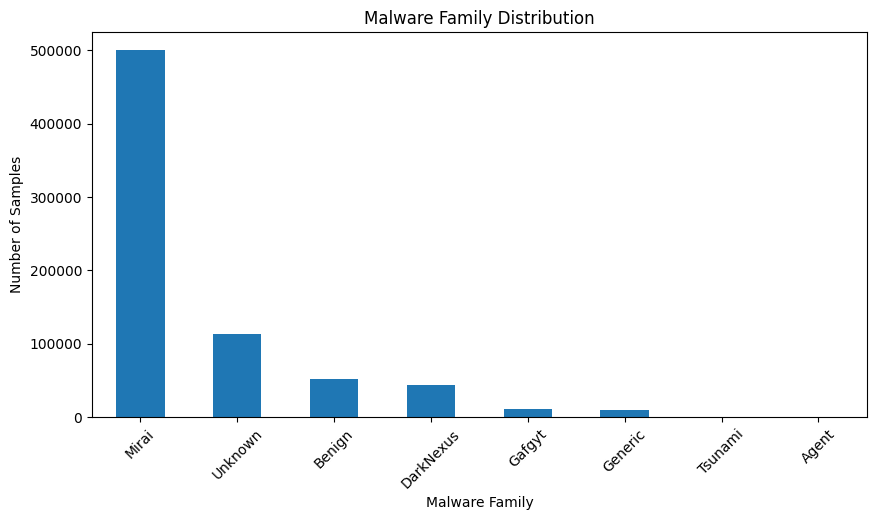

In [16]:
plt.figure(figsize=(10,5))
df['MalwareFamily'].value_counts().plot(kind='bar')
plt.title('Malware Family Distribution')
plt.xlabel('Malware Family')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

## 📈 Visualize Class Distribution

A bar chart provides a clearer view of the number of samples in each malware family, making class **imbalance** easier to identify.

In [17]:
df = df[df['MalwareFamily'] != 'Unknown']

## 🚫 Remove the Unknown Class

The **Unknown** class is removed because it does not provide a specific malware label.

Keeping unlabeled samples may reduce the effectiveness of supervised machine learning models, which require clearly defined target classes.

### Code bellow achieve **Balnced**:

In [18]:
df = df.groupby('MalwareFamily', group_keys=False).apply( lambda x: x.sample( n=4000 if x.name == 'Benign' else min(len(x), 800),random_state=42 )).reset_index(drop=True)

/tmp/ipykernel_58/3857148686.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('MalwareFamily', group_keys=False).apply( lambda x: x.sample( n=4000 if x.name == 'Benign' else min(len(x), 800),random_state=42 )).reset_index(drop=True)


## ⚖️ Balance the Dataset

The dataset is highly imbalanced, with some malware families containing significantly more samples than others.

To reduce this imbalance:

- **Benign** is randomly sampled to **4,000** records.
- Each malware family is randomly sampled to **up to 800** records.
- `random_state=42` is used to ensure reproducible results.

This balanced dataset helps reduce model bias and improves fair learning across different classes.

In [19]:
df['MalwareFamily'].value_counts()

MalwareFamily
Benign       4000
DarkNexus     800
Gafgyt        800
Mirai         800
Generic       800
Tsunami       786
Agent          26
Name: count, dtype: int64

In [20]:
df = df[df['MalwareFamily'] != 'Agent']

## 🗑️ Remove the Agent Class

The **Agent** malware family is removed because it contains only **26 samples**, which is insufficient for effective model training.

Keeping such a small class may introduce bias, reduce model stability, and negatively affect the learning process.

Therefore, the **Agent** class is excluded from the dataset to improve the quality and reliability of the binary classification model.

## ⚖️ Dataset Balancing Strategy

The original dataset is highly imbalanced, with some classes containing many more samples than others.

After several experiments using different sampling sizes, **4,000 Benign samples** and **up to 800 samples from each malware family** were selected because they provided a good balance between class distribution and model performance.

This study focuses on **binary classification**, where:

- **Class 0:** Benign traffic (**4,000 samples**)
- **Class 1:** Malicious traffic, created by combining all malware families into one class (**3,986 samples**)

The malicious class consists of:

- Mirai → **800 samples**
- Gafgyt → **800 samples**
- Generic → **800 samples**
- DarkNexus → **800 samples**
- Tsunami → **786 samples**

For malware families containing fewer than **800 samples**, all available records were retained.

### Mathematical Balance

- Benign traffic = **4,000 samples** → **Class 0**
- Malicious traffic = **800 × 4 + 786 = 3,986 samples** → **Class 1**

This creates an approximately balanced binary dataset:

**Benign : Malicious ≈ 4000 : 3986**

This balance helps reduce model bias and improves fair learning between normal and malicious traffic.

In [21]:
df['MalwareFamily'].value_counts()

MalwareFamily
Benign       4000
DarkNexus     800
Gafgyt        800
Generic       800
Mirai         800
Tsunami       786
Name: count, dtype: int64

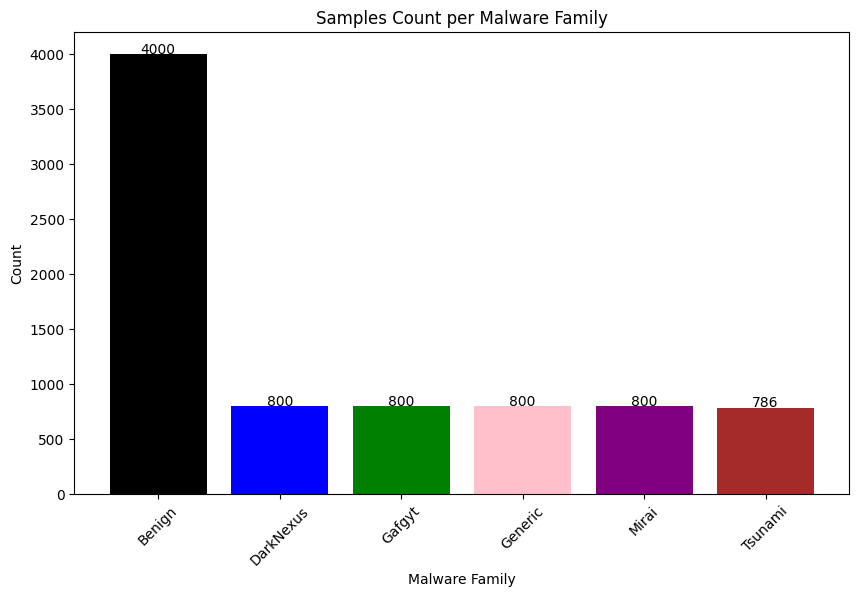

In [22]:
counts = df['MalwareFamily'].value_counts()
colors = ['black', 'blue', 'green', 'pink', 'purple', 'brown', 'orange']
plt.figure(figsize=(10,6))
bars = plt.bar(counts.index, counts.values, color=colors)

plt.title("Samples Count per Malware Family")
plt.xlabel("Malware Family")
plt.ylabel("Count")

plt.xticks(rotation=45)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 5,
             int(yval),
             ha='center')
plt.show()

In [23]:
df['Label'] = df['MalwareFamily'].apply(lambda x: 0 if x == 'Benign' else 1)

In [24]:
df['Label'].value_counts()

Label
0    4000
1    3986
Name: count, dtype: int64

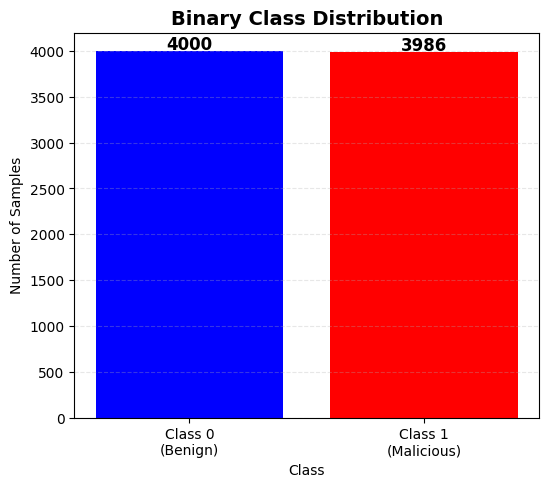

In [25]:
import matplotlib.pyplot as plt

class_counts = df['Label'].value_counts().sort_index()

plt.figure(figsize=(6,5))
bars = plt.bar(
    ['Class 0\n(Benign)', 'Class 1\n(Malicious)'],
    class_counts.values,
    color=['blue', 'red']
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f'{int(height)}',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Binary Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

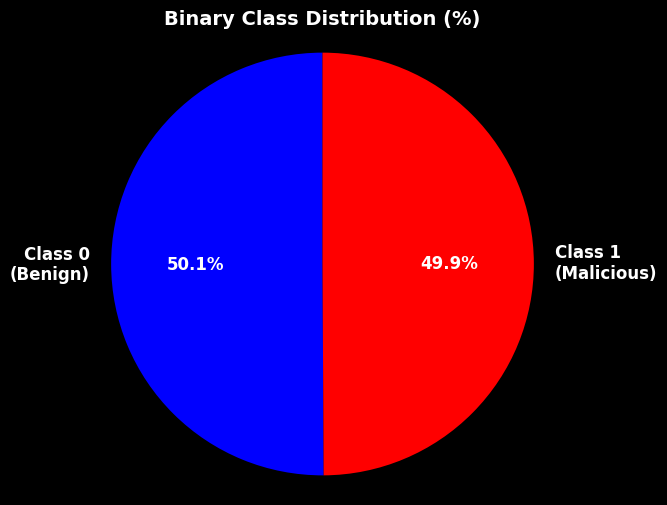

In [26]:

counts = df['Label'].value_counts().sort_index()

labels = ['Class 0\n(Benign)', 'Class 1\n(Malicious)']
colors = ['blue', 'red']

plt.figure(figsize=(6,6), facecolor='black')
plt.gca().set_facecolor('black')
plt.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize':12, 'fontweight':'bold','color':'white'}
)

plt.title('Binary Class Distribution (%)', fontsize=14, fontweight='bold',color='white')

plt.axis('equal') 
plt.show()

In [27]:
df = df.drop('MalwareFamily', axis=1)

## 🗑️ Remove the Original Target Column

The original **`MalwareFamily`** column is removed because it has already been transformed into a binary target variable.

The new **`Label`** column is used as the target for binary classification:

- **0 → Benign traffic**
- **1 → Malicious traffic**

Keeping both target columns is unnecessary and may introduce redundancy during model training.

### Feature Selection (Feature Engineering) :

In [28]:
### df.nunique()   >>> Remove the comment to take note of that.

In [29]:
df = df.drop(columns=[col for col in df.columns if df[col].nunique() <= 1])

## 🗑️ Remove Constant Features

Features with only one unique value are removed because they do not provide any useful information for data analysis or machine learning.

Since these features have no variability, they cannot help distinguish between different samples and may unnecessarily increase the dimensionality of the dataset.

In [30]:
df.corr()['Label']

Header_Length      0.901783
Protocol Type     -0.942875
Time_To_Live       0.284012
Rate               0.422328
fin_flag_number    0.122674
syn_flag_number    0.921332
rst_flag_number    0.259167
psh_flag_number    0.073022
ack_flag_number    0.241362
ack_count          0.241311
syn_count          0.921220
fin_count          0.122674
rst_count          0.259174
HTTP               0.085554
HTTPS              0.039724
DNS               -0.013703
Telnet             0.891712
TCP                0.946993
UDP               -0.946110
DHCP              -0.939204
ARP               -0.293424
ICMP               0.157962
IPv                0.293424
LLC                0.293424
Tot sum           -0.916460
Min               -0.660283
Max               -0.722535
AVG               -0.929702
Std               -0.113525
Tot size          -0.929702
IAT               -0.897344
Number             0.099811
Variance          -0.039212
Label              1.000000
Name: Label, dtype: float64

## 📊 Feature Correlation Analysis

The correlation coefficient is calculated between each feature and the target variable (**Label**).

Correlation analysis helps identify how strongly each feature is related to the target class.

- A value close to **+1** indicates a strong positive correlation.
- A value close to **−1** indicates a strong negative correlation.
- A value close to **0** indicates little or no linear relationship.

Features with higher **absolute correlation** values are generally more informative for binary classification and may contribute more effectively to the machine learning model.

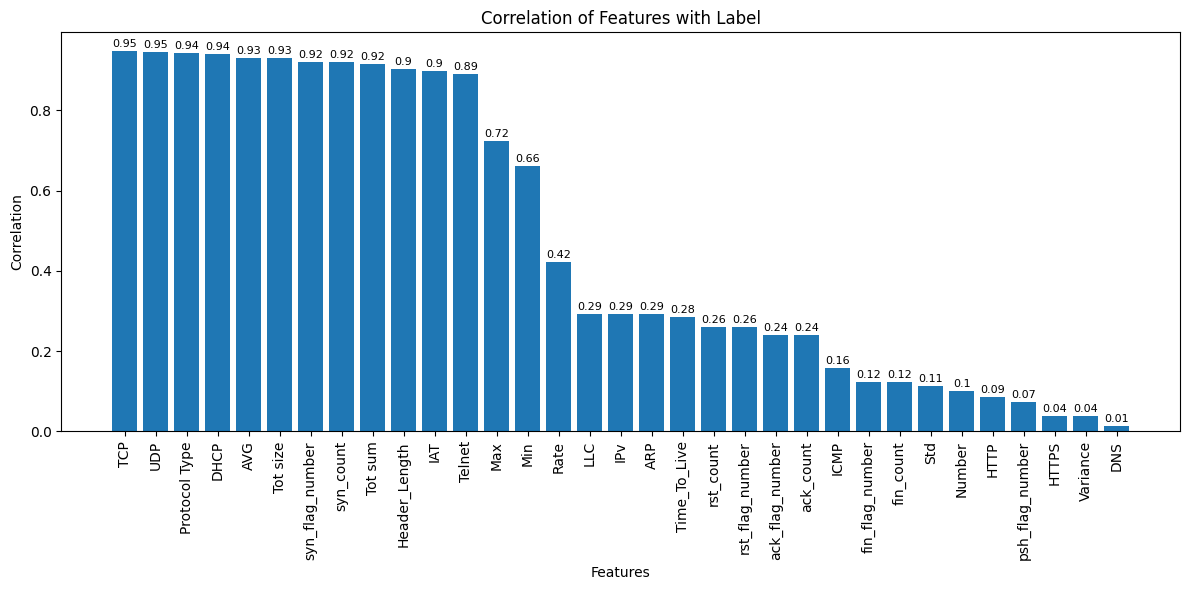

In [31]:
corr = df.corr(numeric_only=True)

target_corr = corr['Label'].abs().sort_values(ascending=False)

target_corr = target_corr.drop('Label')

plt.figure(figsize=(12,6))

bars = plt.bar(target_corr.index, target_corr.values)

plt.title("Correlation of Features with Label")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.xticks(rotation=90)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        round(yval, 2),
        ha='center',
        fontsize=8
    )
plt.tight_layout()
plt.show()

## 📊 Feature Correlation Analysis

To identify the most informative features for malware classification, the absolute Pearson correlation (|r|) between each feature and the target label was calculated.

**The absolute value** was used because both **positive and negative** correlations indicate the strength of the relationship with the target variable. Therefore, only the magnitude of the correlation was considered, regardless of its direction.

Features with higher absolute correlation values have a stronger association with the target label and are generally more informative for machine learning models, while features with lower values contribute less to the classification task.

This visualization ranks all features based on their absolute correlation with the target label, making it easier to identify the most influential predictors.

In [32]:
threshold = 0.2

low_corr_features = target_corr[target_corr < threshold].index.tolist()


df = df.drop(columns=low_corr_features)

print("Deleted Columns:")
print(low_corr_features)

print("\nRemaining Columns:")
print(df.columns)

Deleted Columns:
['ICMP', 'fin_flag_number', 'fin_count', 'Std', 'Number', 'HTTP', 'psh_flag_number', 'HTTPS', 'Variance', 'DNS']

Remaining Columns:
Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'syn_flag_number', 'rst_flag_number', 'ack_flag_number', 'ack_count',
       'syn_count', 'rst_count', 'Telnet', 'TCP', 'UDP', 'DHCP', 'ARP', 'IPv',
       'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Tot size', 'IAT', 'Label'],
      dtype='object')


## 🗑️ Remove Low-Correlation Features

To simplify the dataset and reduce unnecessary information, features with an **absolute correlation lower than 0.20** with the target label were removed.

A threshold of **0.20** was selected because features below this value have a very weak relationship with the target variable and are less likely to improve the classification performance.

Removing weakly correlated features helps to:

- Reduce dataset dimensionality.
- Eliminate less informative variables.
- Improve computational efficiency.
- Potentially enhance model generalization by reducing noise.

The remaining features have stronger relationships with the target label and are therefore retained for model training.

In [33]:
df.shape

(7986, 24)

### 📌 Dataset Shape After Feature Selection

After removing low-correlation features, the dataset size was reduced to **7,986 samples** and **24 features**.

This reduction decreases the dimensionality of the dataset while preserving the most informative features for binary malware classification. As a result, the dataset becomes more efficient for training machine learning models with less computational cost and reduced noise.

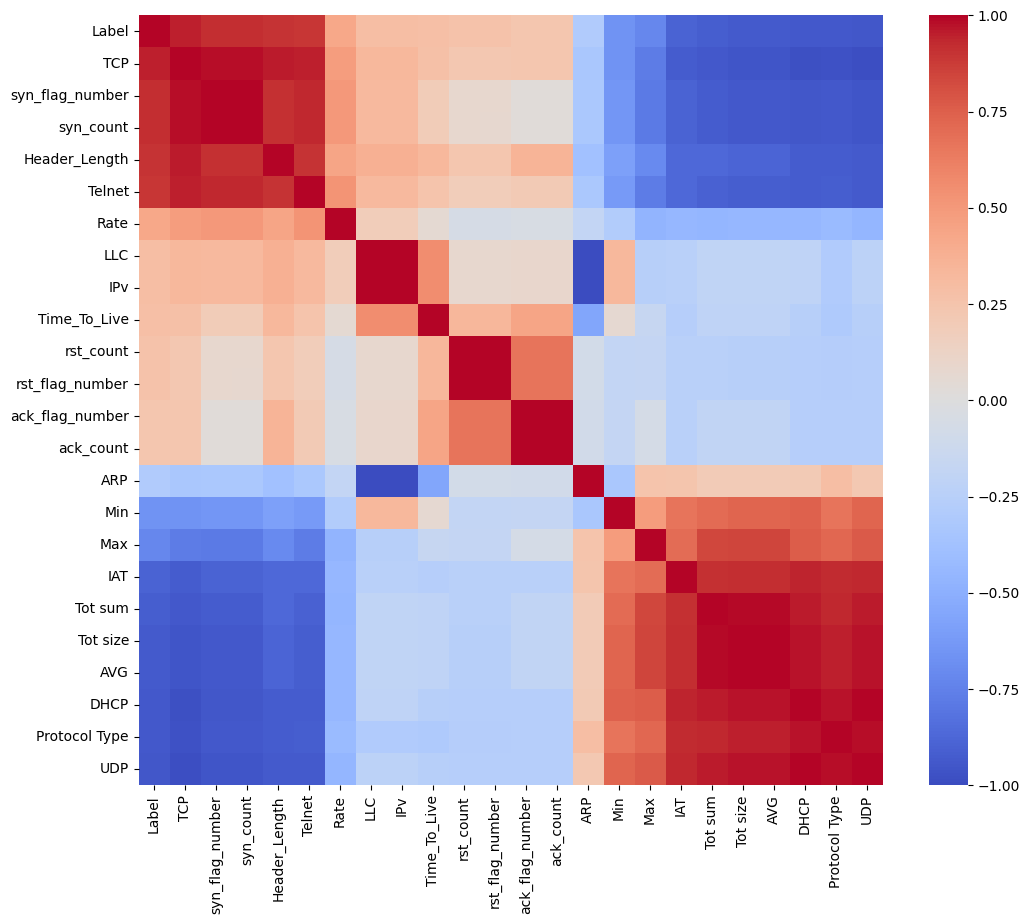

In [34]:
plt.figure(figsize=(12,10))
top_features = df.corr()['Label'].sort_values(ascending=False).index
sns.heatmap(df[top_features].corr(), annot=False, cmap='coolwarm')
plt.show()

## 🔥 Correlation Heatmap

A correlation heatmap was generated to visualize the relationships between the remaining features after feature selection.

The heatmap is based on the **Pearson correlation coefficient**, where correlation values range from **-1 to 1**.

### Interpretation

- 🔴 **Red** indicates a strong positive correlation.
- 🔵 **Blue** indicates a strong negative correlation.
- ⚪ Values close to **0** indicate little or no linear relationship.

This visualization helps identify:
- Features that are strongly related to the target label.
- Groups of highly correlated features.
- Possible redundant features that may contain similar information.

## ✂️ Split the Dataset

Before training the machine learning models, the dataset is divided into **features (X)** and the **target variable (y)**.

The preprocessing steps performed are:

- Separate the input features (`X`) from the target label (`y`).
- Replace any infinite values (`±∞`) with `NaN`.
- Fill missing values using the **median** of each feature.
- Split the dataset into **70% training data** and **30% testing data**.
- Apply **stratified sampling** to preserve the class distribution in both the training and testing sets.
- Set `random_state=42` to ensure reproducible results.

In [35]:
X = df.drop("Label", axis=1)
y = df["Label"]
X = X.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split( X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

### 📌 Why Stratified Sampling?

The `stratify=y` parameter ensures that both the training and testing datasets maintain approximately the same proportion of **Benign** and **Malicious** samples as the original dataset. This helps produce a fair and reliable evaluation of the machine learning models.

#  🌲---RFC Model ---

In [36]:
Rmodel = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42
)


### ⚙️ Model Configuration

The following code initializes the **Random Forest Classifier** by setting its main hyperparameters before training.

- **`n_estimators=100`** → Builds 100 decision trees.
- **`max_depth=5`** → Limits each tree depth to reduce overfitting.
- **`min_samples_split=2`** → A node must contain at least 2 samples before it can be split.
- **`min_samples_leaf=1`** → Each leaf node must contain at least one sample.
- **`max_features="sqrt"`** → Uses the square root of the total number of features when searching for the best split.
- **`bootstrap=True`** → Each tree is trained on a random bootstrap sample of the training data.
- **`random_state=42`** → Ensures reproducible and consistent results across different runs.

Confusion Matrix RFC:
 [[1200    0]
 [  36 1160]]
Accuracy: 0.9849749582637729
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      1200
           1       1.00      0.97      0.98      1196

    accuracy                           0.98      2396
   macro avg       0.99      0.98      0.98      2396
weighted avg       0.99      0.98      0.98      2396



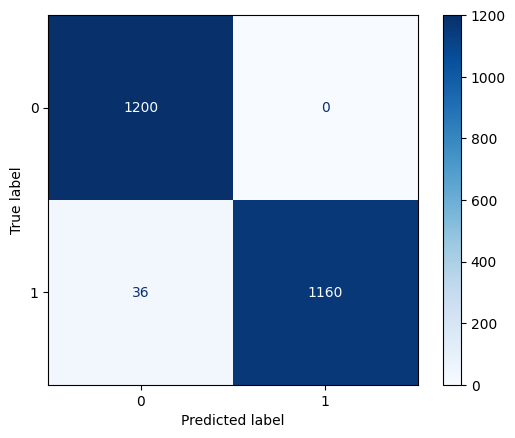

In [37]:
Rmodel.fit(X_train, y_train)
y_pred = Rmodel.predict(X_test)
cmR = confusion_matrix(y_test, y_pred)

print("Confusion Matrix RFC:\n", cmR)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cmR, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

### 🚀 Model Training and Evaluation

After configuring the Random Forest model, it is trained using the training dataset and then tested on unseen data.

The following steps are performed:

- **Train the model** using the training data (`fit`).
- **Predict** the labels of the testing dataset (`predict`).
- **Generate the Confusion Matrix** to compare actual and predicted classes.
- **Calculate the Accuracy** to measure the overall classification performance.
- **Display the Classification Report**, including Precision, Recall, and F1-score.
- **Visualize the Confusion Matrix** for an easier interpretation of the model's predictions.

### 📌 Observation

The Random Forest model achieved an **accuracy of approximately 98.5%**, demonstrating excellent performance in distinguishing between benign and malicious network traffic.

The confusion matrix indicates that:
- All **1,200 benign samples** were classified correctly.  >>> **TN**  (True Negatives )
- **1,160 malicious samples** were correctly identified.   >>> **TP**  (True Positives )
- Only **36 malicious samples** were misclassified as benign.  >>>**FN** (False Negatives)
- No benign samples were incorrectly classified as malicious.  >>>**FP** (False Positives)

Overall, the model shows high precision, recall, and F1-score, making it highly effective for binary malware detection.

In [38]:
train_pred = Rmodel.predict(X_train)
print("Training Accuracy RFC:", accuracy_score(y_train, train_pred))
print("Testing Accuracy  RFC :", accuracy_score(y_test, y_pred))

Training Accuracy RFC: 0.9858676207513417
Testing Accuracy  RFC : 0.9849749582637729


# 📌 **Observation**

To check for **overfitting**, compare the training accuracy with the testing accuracy.

- **Training Accuracy:** 98.59%
- **Testing Accuracy:** 98.50%

The difference between them is **very small (≈ 0.1%)**, indicating that the model generalizes well to unseen data and **does not suffer from significant overfitting**.

# 🚀 **XGBOOST Model**

In [48]:
grid_parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.01, 0.2],
    'max_depth': [3, 5, 7]
}


grid_model = GridSearchCV(
    XGBClassifier(random_state=0),
    grid_parameters,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

📌 **Hyperparameter Tuning using GridSearchCV**

Before training the XGBoost model, **GridSearchCV** is used to search for the best combination of hyperparameters.

The following parameters are evaluated:

- **n_estimators:** Number of boosting trees.
- **learning_rate:** Controls the learning speed.
- **max_depth:** Maximum depth of each decision tree.

The combination that achieves the highest cross-validation accuracy is selected automatically.

In [49]:
grid_model.fit(X_train, y_train)
print("Best Parameters:", grid_model.best_params_)
print("Best Score:", grid_model.best_score_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
Best Score: 0.9846153846153847


**The best hyperparameters found by **GridSearchCV** are:**

- **learning_rate = 0.01**
- **max_depth = 5**
- **n_estimators = 100**

These parameters achieved the highest cross-validation accuracy of approximately **98.46%**, indicating a well-balanced model with strong generalization performance.

Confusion Matrix XGBOOST:
 [[1200    0]
 [  36 1160]]
Accuracy: 0.9849749582637729
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      1200
           1       1.00      0.97      0.98      1196

    accuracy                           0.98      2396
   macro avg       0.99      0.98      0.98      2396
weighted avg       0.99      0.98      0.98      2396



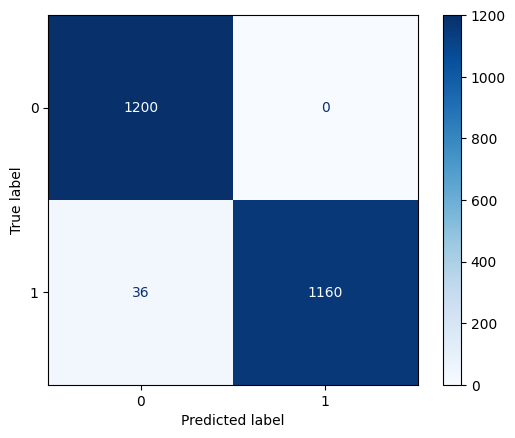

In [40]:
y_pred = grid_model.predict(X_test)
cmG = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Confusion Matrix XGBOOST:\n", cmG)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cmG, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

### The XGBoost model achieved an **accuracy of approximately 98.5%**, 
demonstrating excellent performance in distinguishing between benign and malicious network traffic.

The confusion matrix indicates that:

- All **1,200 benign samples** were classified correctly. → **TN (True Negatives)**
- **1,160 malicious samples** were correctly identified. → **TP (True Positives)**
- Only **36 malicious samples** were misclassified as benign. → **FN (False Negatives)**
- No benign samples were incorrectly classified as malicious. → **FP (False Positives)**

Overall, the XGBoost model achieved high **precision**, **recall**, and **F1-score**, making it highly effective for binary malware detection.

In [41]:
train_pred = grid_model.predict(X_train)
print("Training Accuracy XGBOOST:", accuracy_score(y_train, train_pred))
print("Testing Accuracy XGBOOST:", accuracy_score(y_test, y_pred))

Training Accuracy XGBOOST: 0.9853309481216458
Testing Accuracy XGBOOST: 0.9849749582637729



### To check for **overfitting**, 
compare the training accuracy with the testing accuracy.

- **Training Accuracy:** 98.53%
- **Testing Accuracy:** 98.50%

The difference between them is **very small (≈ 0.03%)**, indicating that the XGBoost model generalizes well to unseen data and **does not suffer from significant overfitting**.

# ⚙️ Support Vector Machine (SVM) model

In [44]:
smodel = SVC(kernel='rbf', C=1.0, gamma='scale')
smodel.fit(X_train, y_train)



SVC()

### **Support Vector Machine (SVM) Model**

The **Support Vector Machine (SVM)** classifier is trained using the **RBF (Radial Basis Function)** kernel, which is effective for handling non-linear classification problems.

The model uses:
- **Kernel:** `rbf`
- **C = 1.0:** Controls the trade-off between maximizing the margin and minimizing classification errors.>>(Regularization)
- **Gamma = "scale":** Automatically computes the gamma value based on the input features.

After training, the model is used to predict the labels of the testing dataset.

Accuracy SVM: 0.9661936560934892

Confusion Matrix:
 [[1185   15]
 [  66 1130]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1200
           1       0.99      0.94      0.97      1196

    accuracy                           0.97      2396
   macro avg       0.97      0.97      0.97      2396
weighted avg       0.97      0.97      0.97      2396



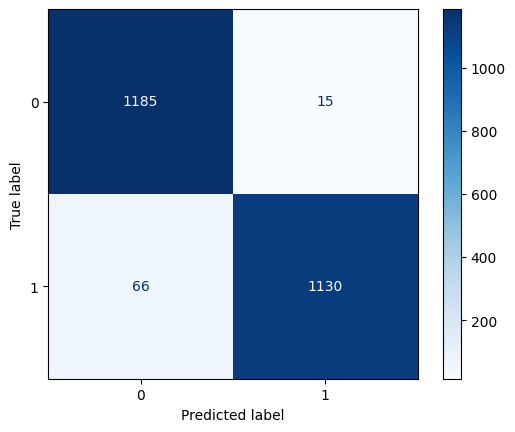

In [45]:
y_pred = smodel.predict(X_test)
CMS = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Accuracy SVM:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=CMS, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

### The SVM model achieved an **accuracy of approximately 96.6%**, 
demonstrating strong performance in distinguishing between benign and malicious network traffic.

The confusion matrix indicates that:

- **1,185 benign samples** were classified correctly. → **TN (True Negatives)**
- **1,130 malicious samples** were correctly identified. → **TP (True Positives)**
- **66 malicious samples** were misclassified as benign. → **FN (False Negatives)**
- **15 benign samples** were incorrectly classified as malicious. → **FP (False Positives)**

Overall, the SVM model achieved high **precision**, **recall**, and **F1-score**, making it effective for binary malware detection, although its performance is slightly lower than the Random Forest and XGBoost models

In [50]:
train_pred = smodel.predict(X_train)
print("Training Accuracy SVM:", accuracy_score(y_train, train_pred))
print("Testing Accuracy SVM:", accuracy_score(y_test, y_pred))

Training Accuracy SVM: 0.9713774597495528
Testing Accuracy SVM: 0.9661936560934892


### To check for **overfitting** :
compare the training accuracy with the testing accuracy.

- **Training Accuracy:** 97.14%
- **Testing Accuracy:** 96.62%

The difference between them is **small (≈ 0.005)**, indicating that the SVM model generalizes well to unseen data and **does not suffer from significant overfitting**.

# 📈 Logistic Regression Model

In [53]:
LR = LogisticRegression(max_iter=10000, random_state=42)
LR.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=42)

### 📈 **Logistic Regression Model**

The **Logistic Regression** classifier is trained to perform binary classification by estimating the probability that each sample belongs to either the benign or malicious class.

The model uses:
- **max_iter = 10000:** Increases the maximum number of iterations to ensure the optimization process converges successfully.
- **random_state = 42:** Ensures reproducible and consistent training results.

After training, the model is used to classify network traffic into **Class 0 (Benign)** or **Class 1 (Malicious)**.

### 🔍 Code Explanation

- `LogisticRegression(...)` creates the Logistic Regression model.
- `max_iter=10000` allows sufficient iterations for the model to converge.
- `random_state=42` ensures reproducible results.
- `LR.fit(X_train, y_train)` trains the model using the training dataset.

--- Logistic Regression Results ---
Training Accuracy LR: 0.9849731663685152
Testing Accuracy LR: 0.9841402337228714

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1200
           1       1.00      0.97      0.98      1196

    accuracy                           0.98      2396
   macro avg       0.98      0.98      0.98      2396
weighted avg       0.98      0.98      0.98      2396



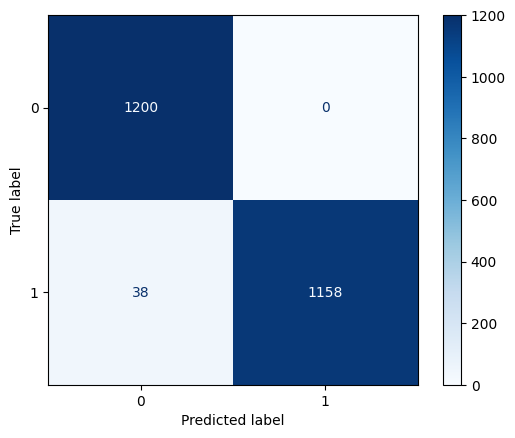

In [54]:
y_pred = LR.predict(X_test)
train_pred = LR.predict(X_train)
CML = confusion_matrix(y_test, y_pred)

print("--- Logistic Regression Results ---")
print("Training Accuracy LR:", accuracy_score(y_train, train_pred))
print("Testing Accuracy LR:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=CML, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

### The Logistic Regression model achieved an **accuracy of approximately 98.4%**,
demonstrating excellent performance in distinguishing between benign and malicious network traffic.

The confusion matrix indicates that:

- All **1,200 benign samples** were classified correctly. → **TN (True Negatives)**
- **1,158 malicious samples** were correctly identified. → **TP (True Positives)**
- Only **38 malicious samples** were misclassified as benign. → **FN (False Negatives)**
- No benign samples were incorrectly classified as malicious. → **FP (False Positives)**

Overall, the Logistic Regression model achieved high **precision**, **recall**, and **F1-score**, making it highly effective for binary malware detection.

In [56]:
train_pred = LR.predict(X_train)
print("Training Accuracy LogisticRegression:", accuracy_score(y_train, train_pred))
print("Testing Accuracy LogisticRegression:", accuracy_score(y_test, y_pred))

Training Accuracy LogisticRegression: 0.9849731663685152
Testing Accuracy LogisticRegression: 0.9841402337228714


### To check for **overfitting**, 
compare the training accuracy with the testing accuracy.

- **Training Accuracy:** 98.50%
- **Testing Accuracy:** 98.41%

The difference between them is **very small (≈ 0.001)**, indicating that the Logistic Regression model generalizes well to unseen data and **does not suffer from significant overfitting**.

# 💡 **LightGBM Model**

In [58]:
GBMmodel = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

GBMmodel.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2790, number of negative: 2800
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000599 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1547
[LightGBM] [Info] Number of data points in the train set: 5590, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499106 -> initscore=-0.003578
[LightGBM] [Info] Start training from score -0.003578


LGBMClassifier(learning_rate=0.05, n_estimators=500, random_state=42)

### 🌿 **LightGBM Model**

The **LightGBM (Light Gradient Boosting Machine)** classifier is trained for binary classification using a gradient boosting framework based on decision trees.

The model uses:
- **n_estimators = 500:** Builds 500 boosting trees.
- **learning_rate = 0.05:** Controls the contribution of each tree, improving generalization.
- **max_depth = -1:** Allows trees to grow without a fixed depth limit.
- **num_leaves = 31:** Specifies the maximum number of leaves in each tree.
- **random_state = 42:** Ensures reproducible training results.

After training, the model is used to classify network traffic into **Class 0 (Benign)** or **Class 1 (Malicious)**.

### 🔍 Code Explanation

- `LGBMClassifier(...)` creates the LightGBM classification model.
- `n_estimators=500` specifies the number of boosting trees.
- `learning_rate=0.05` controls how much each tree contributes to the final model.
- `max_depth=-1` allows the trees to grow without a depth limit.
- `num_leaves=31` sets the maximum number of leaves for each tree.
- `random_state=42` ensures reproducible results.
- `GBMmodel.fit(X_train, y_train)` trains the model using the training dataset.

Accuracy  LightGBM: 0.9828881469115192

Confusion Matrix:
 [[1195    5]
 [  36 1160]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1200
           1       1.00      0.97      0.98      1196

    accuracy                           0.98      2396
   macro avg       0.98      0.98      0.98      2396
weighted avg       0.98      0.98      0.98      2396



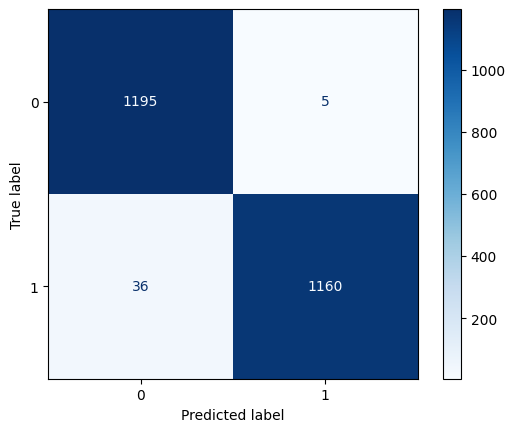

In [59]:
y_pred = GBMmodel.predict(X_test)
CMGBM = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)


print("Accuracy  LightGBM:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=CMGBM, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

### The LightGBM model achieved an **accuracy of approximately 98.3%**, 
demonstrating excellent performance in distinguishing between benign and malicious network traffic.

The confusion matrix indicates that:

- **1,195 benign samples** were classified correctly. → **TN (True Negatives)**
- **1,160 malicious samples** were correctly identified. → **TP (True Positives)**
- Only **36 malicious samples** were misclassified as benign. → **FN (False Negatives)**
- Only **5 benign samples** were incorrectly classified as malicious. → **FP (False Positives)**

Overall, the LightGBM model achieved high **precision**, **recall**, and **F1-score**, making it highly effective for binary malware detection.

In [60]:
train_pred = GBMmodel.predict(X_train)
print("Training Accuracy LightGBM:", accuracy_score(y_train, train_pred))
print("Testing Accuracy LightGBM:", accuracy_score(y_test, y_pred))

Training Accuracy LightGBM: 0.992665474060823
Testing Accuracy LightGBM: 0.9828881469115192


### To check for **overfitting** :
compare the training accuracy with the testing accuracy.

- **Training Accuracy:** 99.27%
- **Testing Accuracy:** 98.29%

The difference between them is **small (≈ 0.01)**, indicating that the LightGBM model generalizes well to unseen data and **does not suffer from significant overfitting**, although the gap is slightly larger than that observed in the other models.

# 🧠 Naive Bayes Model

In [61]:
nb_model = GaussianNB(
    var_smoothing=1e-10
)

nb_model.fit(X_train, y_train)

GaussianNB(var_smoothing=1e-10)

## 🧠 **Naive Bayes Model**

The **Gaussian Naive Bayes** classifier is trained for binary classification using Bayes' theorem. It assumes that all features are independent and follow a Gaussian (normal) distribution.

The model uses:
- **var_smoothing = 1e-10:** Adds a small value to the feature variances to improve numerical stability and prevent division by zero.

After training, the model is used to classify network traffic into **Class 0 (Benign)** or **Class 1 (Malicious)**.
### 🔍 Code Explanation

- `GaussianNB(...)` creates the Gaussian Naive Bayes classifier.
- `var_smoothing=1e-10` adds a very small value to the variance of each feature to improve numerical stability.
- `nb_model.fit(X_train, y_train)` trains the model using the training dataset.

Accuracy  Naïve Bayes: 0.9820534223706177

Confusion Matrix:
 [[1193    7]
 [  36 1160]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1200
           1       0.99      0.97      0.98      1196

    accuracy                           0.98      2396
   macro avg       0.98      0.98      0.98      2396
weighted avg       0.98      0.98      0.98      2396



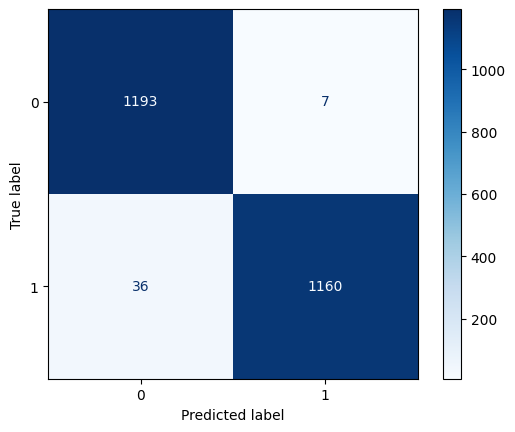

In [62]:
y_pred = nb_model.predict(X_test)
CMnb = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)


print("Accuracy  Naïve Bayes:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=CMnb, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

### The Naive Bayes model achieved an **accuracy of approximately 98.2%**,
demonstrating strong performance in distinguishing between benign and malicious network traffic.

The confusion matrix indicates that:

- All **1,160 malicious samples** were correctly identified. >>> **TP (True Positives)**
- **1,193 benign samples** were correctly classified. >>> **TN (True Negatives)**
- Only **36 malicious samples** were misclassified as benign. >>> **FN (False Negatives)**
- Only **7 benign samples** were incorrectly classified as malicious. >>> **FP (False Positives)**

Overall, the Naive Bayes model achieved high precision, recall, and F1-score, making it an effective classifier for malware detection.

In [63]:
train_pred = nb_model.predict(X_train)
print("Training Accuracy LightGBM:", accuracy_score(y_train, train_pred))
print("Testing Accuracy LightGBM:", accuracy_score(y_test, y_pred))

Training Accuracy LightGBM: 0.9822898032200358
Testing Accuracy LightGBM: 0.9820534223706177


### To check for **overfitting**:
compare the training accuracy with the testing accuracy.

- **Training Accuracy:** 98.23%
- **Testing Accuracy:** 98.21%

The difference between them is **very small (≈ 0.0002)**, indicating that the model generalizes well to unseen data and **does not suffer from significant overfitting**.